In [1]:
import numpy as np
import matplotlib.pyplot as plt
from causal_gym.envs.mnist import MNISTPCH

In [2]:
# Create environment
env = MNISTPCH(seed=42)

print("=== Reset Test ===")
obs, info = env.reset()
print("Reset obs:", obs)
print("Reset info (should include u):", info)

=== Reset Test ===
Reset obs: None
Reset info (should include u): {}


In [3]:
print("\n=== do() Test ===")
for x in [0, 1]:
    obs, _, _, _, info = env.do(x)
    print(f"Action: {x}, X: {info['x']}, U: {info['u']}")
    print("Observation shape:", obs.shape)
    assert info["x"] == x
    assert obs.shape == (1, 28, 28)


=== do() Test ===
Action: 0, X: 0, U: 1
Observation shape: (1, 28, 28)
Action: 1, X: 1, U: 1
Observation shape: (1, 28, 28)


In [4]:
print("\n=== see() Test ===")
for _ in range(3):
    x, obs, _, _, _, info = env.see()
    print(f"Behavior policy: U={info['u']} → X={info['x']}")
    assert x == info["x"]


=== see() Test ===
Behavior policy: U=1 → X=0
Behavior policy: U=0 → X=1
Behavior policy: U=1 → X=0


In [5]:
print("\n=== step() Test ===")
env.reset()
obs, r, done, trunc, info = env.env.step(1)
print("Step output - obs shape:", obs.shape)
print("Reward:", r, "Done:", done, "Truncated:", trunc)


=== step() Test ===
Step output - obs shape: (1, 28, 28)
Reward: 0.0 Done: True Truncated: False



=== render() Test ===


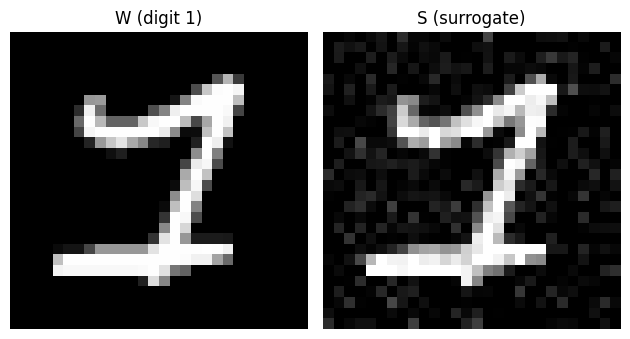

In [6]:
print("\n=== render() Test ===")
env.render()

In [8]:
print("\n=== get_graph() Test ===")
nodes, base, conf = env.env.get_graph
print("Nodes:", nodes)
print("Directed edges matrix (base):")
print(np.array(base))
print("Confounding matrix (conf):")
print(np.array(conf))


=== get_graph() Test ===
Nodes: {0: 'X', 1: 'W', 2: 'S', 3: 'Y'}
Directed edges matrix (base):
[[0 1 0 0]
 [0 0 1 0]
 [0 0 0 1]
 [0 0 0 0]]
Confounding matrix (conf):
[[0 0 1 0]
 [0 0 0 0]
 [1 0 0 0]
 [0 0 0 0]]


In [9]:
print("\n=== Seeding Determinism Test ===")
env1 = MNISTPCH(seed=123)
env2 = MNISTPCH(seed=123)
_, _ = env1.reset(seed=99)
_, _ = env2.reset(seed=99)
_, obs1, *_ = env1.see()
_, obs2, *_ = env2.see()
print("obs1 == obs2:", np.allclose(obs1, obs2))


=== Seeding Determinism Test ===
obs1 == obs2: True
